In [21]:
import NeuralImplicit as NI
import network_defs as net_defs
import torch
import importlib
import matplotlib.pyplot as plt
importlib.reload(net_defs)
importlib.reload(NI)
#set torch default dtype to float64
torch.set_default_dtype(torch.float64)


In [22]:
architecture = [2, 256,256,256,256,3]
model = net_defs.Siren_jo(architecture=architecture,outermost_linear=True, first_omega_0=15, hidden_omega_0=30)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.8)


Number of parameters: 198915


In [25]:
NUM_EPOCHS = 5000
BATCH_SIZE = 1024
FUN_NUM = 2
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0,
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      use_scheduler=True, 
                      device=torch.device('cpu'))


Epoch [0], Loss: 8.75475346523231e-05, Acc: 8.75475346523231e-05
Epoch [499], Loss: 8.408657064861471e-05, Acc: 8.408657064861471e-05
Epoch [999], Loss: 8.525324093826671e-05, Acc: 8.525324093826671e-05
Epoch [1499], Loss: 8.591998713029481e-05, Acc: 8.591998713029481e-05
Epoch [1999], Loss: 8.666933888198915e-05, Acc: 8.666933888198915e-05
Epoch [2499], Loss: 7.776370643545708e-05, Acc: 7.776370643545708e-05
Epoch [2999], Loss: 9.016417157641551e-05, Acc: 9.016417157641551e-05
Epoch [3499], Loss: 8.17132107003354e-05, Acc: 8.17132107003354e-05
Epoch [3999], Loss: 7.177294212091602e-05, Acc: 7.177294212091602e-05
Epoch [4499], Loss: 7.845837184881876e-05, Acc: 7.845837184881876e-05
Epoch [4999], Loss: 7.551431757671106e-05, Acc: 7.551431757671106e-05


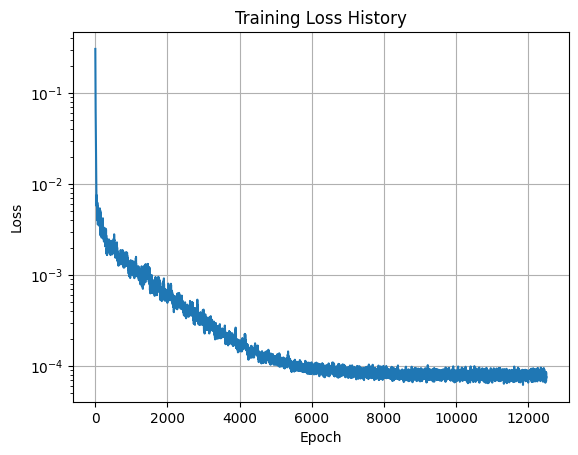

In [26]:
plt.plot(model.loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.grid()
plt.show()

In [27]:
importlib.reload(NI)
NI.evaluate_model_random_points(model, function_case=2,N=10000)

Model evaluation on N=10000 random points (function_case=2):
  Value errors: mean_abs=8.075728e-05, max_abs=7.515161e-03, L2=3.258583e-04
  Grad-norm errors (|grad|-1): mean_abs=7.801646e-03, max_abs=9.424908e-01, L2=4.316488e-02


{'N': 10000,
 'function_case': 2,
 'global': {'value_mean_abs_error': 8.075728046953894e-05,
  'value_max_abs_error': 0.007515161370269918,
  'value_l2_error': 0.0003258583024897442,
  'grad_norm_mean_abs_error': 0.007801646168227383,
  'grad_norm_max_abs_error': 0.9424908151184239,
  'grad_norm_l2_error': 0.043164881396930595}}

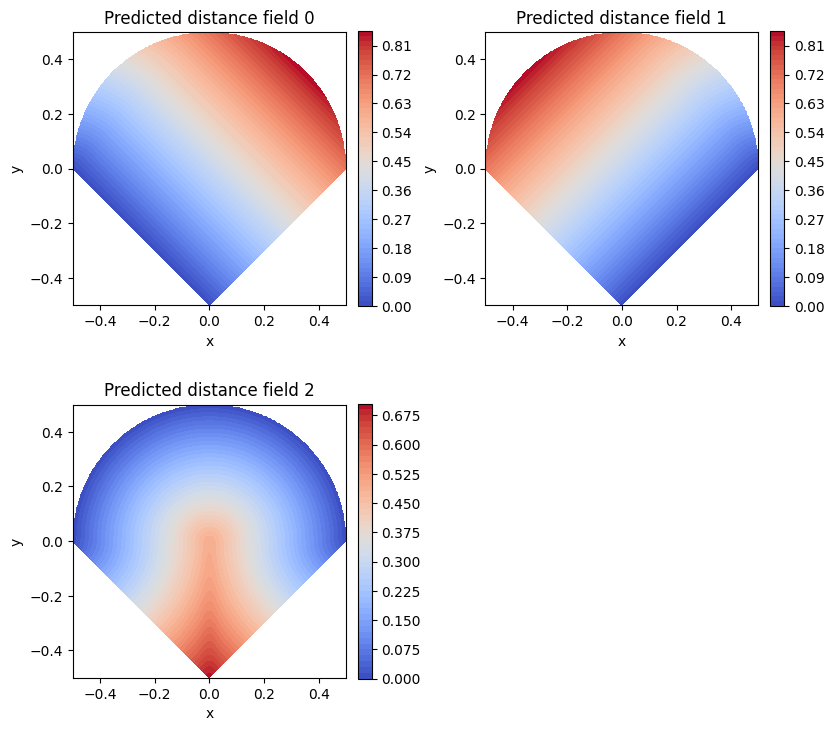

(<Figure size 840x760 with 7 Axes>,
 array([[<Axes: title={'center': 'Predicted distance field 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Predicted distance field 1'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Predicted distance field 2'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[0.32107399, 0.32531369, 0.25769879],
        [0.31919298, 0.32508603, 0.2567783 ],
        [0.31731231, 0.32490313, 0.2558354 ],
        ...,
        [0.61300591, 0.41430357, 0.01765348],
        [0.6103534 , 0.41449428, 0.01897738],
        [0.60768264, 0.4146995 , 0.02035166]]))

In [28]:
NI.plot_nn_distance_fields(model,extent=[-0.5,0.5,-0.5,0.5],fun_num=2,mask_outside_domain=True, device=torch.device('cpu'))

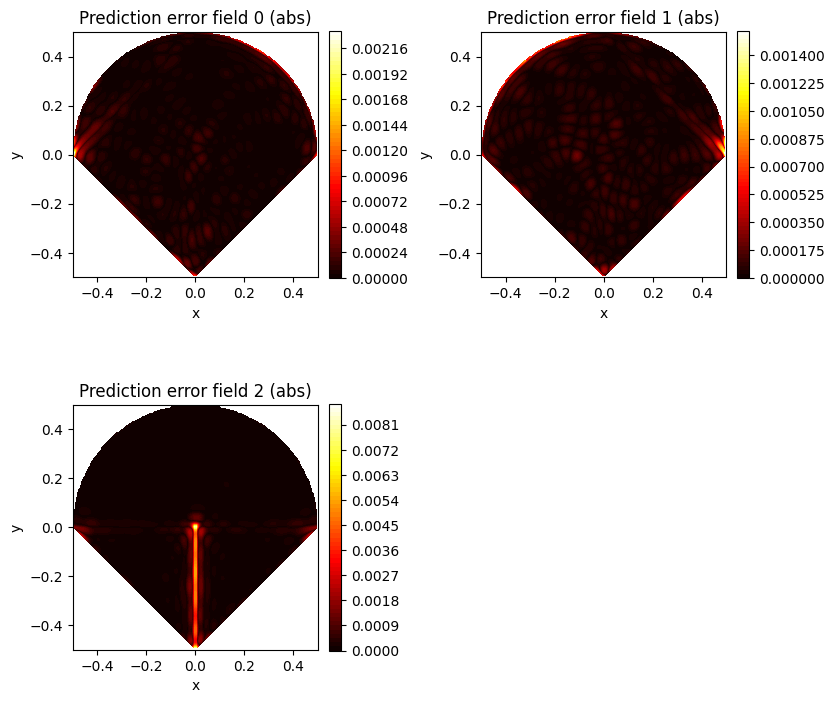

(<Figure size 840x760 with 7 Axes>,
 array([[<Axes: title={'center': 'Prediction error field 0 (abs)'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Prediction error field 1 (abs)'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Prediction error field 2 (abs)'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[0.0324794 , 0.17468631, 0.24230121],
        [0.03269723, 0.17512292, 0.23914427],
        [0.03291483, 0.17543025, 0.23607167],
        ...,
        [0.43526879, 0.07598717, 0.18489937],
        [0.44408768, 0.08067222, 0.1859155 ],
        [0.45297754, 0.0853005 , 0.18675512]]))

In [29]:
NI.plot_nn_prediction_error(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=2,device=torch.device('cpu'))

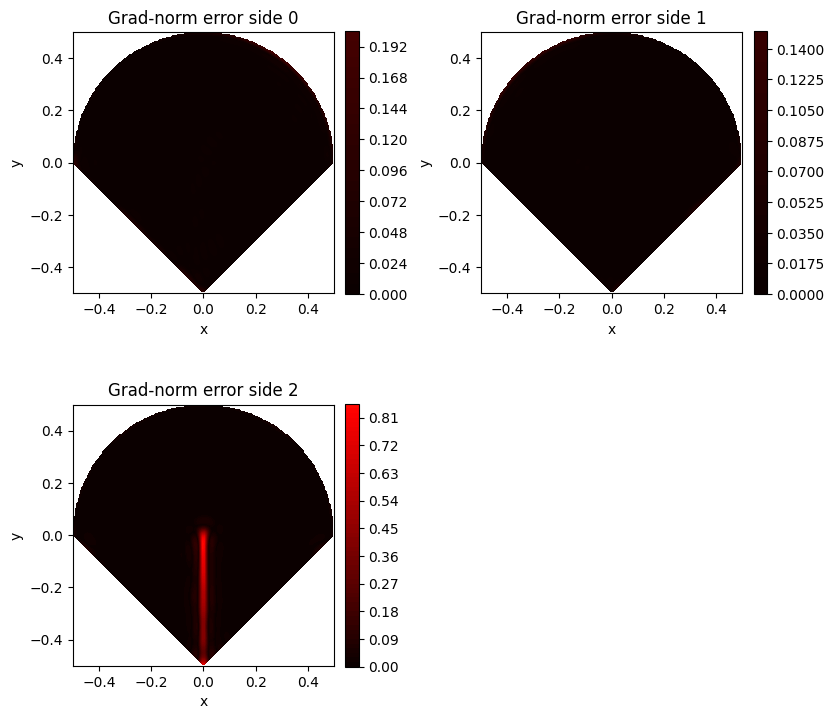

(<Figure size 840x760 with 7 Axes>,
 array([[<Axes: title={'center': 'Grad-norm error side 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Grad-norm error side 1'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Grad-norm error side 2'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[[6.74630302e-02, 8.29784037e-01, 6.01124246e-01],
         [9.30680177e-02, 8.45153623e-01, 5.83546278e-01],
         [1.19777466e-01, 8.53429845e-01, 5.68125289e-01],
         ...,
         [2.98022352e-01, 8.97061563e-01, 6.92308834e-01],
         [2.94216547e-01, 9.43034084e-01, 7.53071273e-01],
         [2.90940363e-01, 9.81204036e-01, 8.06416333e-01]],
 
        [[1.13910661e-01, 8.26920701e-01, 5.94215295e-01],
         [1.40886401e-01, 8.41278091e-01, 5.75326551e-01],
         [1.68875557e-01, 8.48722165e-01, 5.58562181e-01],
         ...,
         [2.59739431e-01, 8.82723861e-01, 6.68356074e-01],
         [2.56675886e-01, 9.29425811e-01, 7.3205359

In [30]:
NI.plot_local_per_side_gradient_error(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=2,device=torch.device('cpu'))

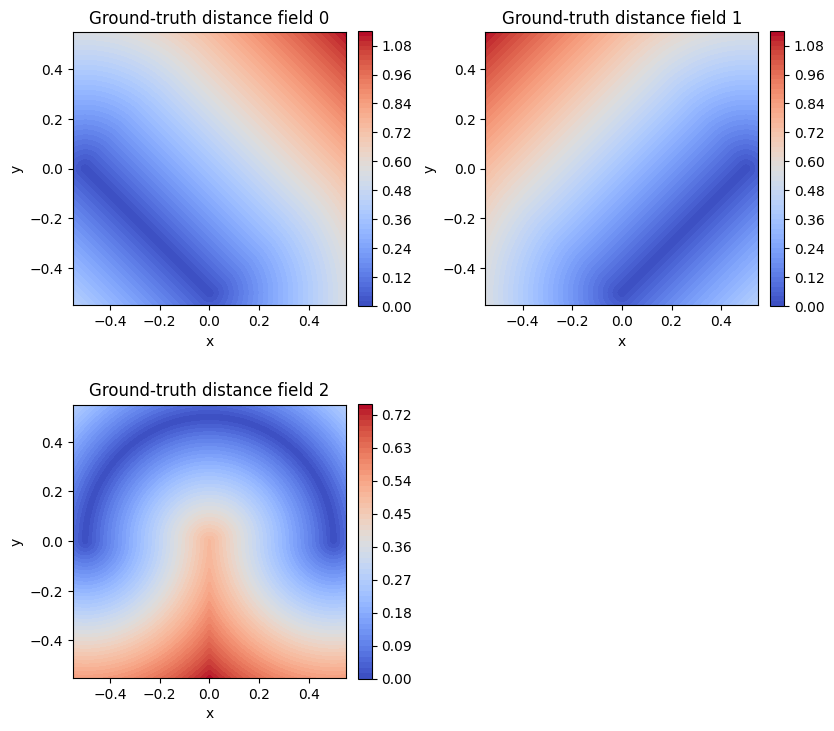

(<Figure size 840x760 with 7 Axes>,
 array([[<Axes: title={'center': 'Ground-truth distance field 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Ground-truth distance field 1'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Ground-truth distance field 2'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[0.42426407, 0.55226805, 0.55226805],
        [0.42166267, 0.55194714, 0.54860433],
        [0.41906128, 0.55165057, 0.54494082],
        ...,
        [1.12616806, 0.54494082, 0.27263218],
        [1.12876945, 0.54860433, 0.27522043],
        [1.13137085, 0.55226805, 0.27781746]]))

In [13]:
importlib.reload(NI)
# Ground-truth visualization for testcase 2 (2 straight sides + 1 curved arc)
case2_params = {
    "radius": 0.5,
    "center": (0.0, 0.0),
    "apex": (0.0, -0.5),
}

NI.plot_ground_truth_distance_fields(
    resolution=300,
    extent=(-0.55, 0.55, -0.55, 0.55),
    fun_num=2,
    data_gen_params=case2_params,
    mask_outside_domain=False,
    device=torch.device('cpu'),
)

In [ ]:
import multi_SDF as SDF
